# 9 — What went wrong

*Series: **Bayesian fluorescence decays**, notebook 9 of 11.*

**What this notebook is.** Every mistake in this project that was serious
enough to change a result, with the measurement that caught it. Not a
confession — a reference. Each of these was plausible enough to survive review,
and several produced numbers that looked fine.

They fall into three kinds, and the kinds matter more than the individual
bugs:

* **wrong answers that fit the data**, which no fit statistic can catch;
* **silent losses**, where something stopped working and reported nothing;
* **checks that could not fail**, which are the most expensive of all because
  they look like evidence.

The cells below re-run the ones that are cheap to re-run.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt, torch
import bd
bd.keep_inline()
rng = np.random.default_rng(0)

## 1. Weighting the residuals by the data (wrong answer, good fit)

The Pearson residual of a Poisson count divides by the square root of the
**model**, $\sqrt\lambda$. Dividing by the square root of the **data**,
$\sqrt y$, is the Neyman weighting, and it is the natural thing to write
because the data are what you have.

It biases every amplitude downwards, because a bin that fluctuated low is given
more weight than one that fluctuated high. In a decay's tail, where counts are
a few per bin and the long-distance information lives, the effect is large.

This was in this project's package in several places and was fixed with tests
pinning it. The cell measures the bias on the simplest possible problem:
estimate one rate from Poisson counts by weighted least squares.

truth 3.0000
  weighted by the model: 2.9987  (bias -0.04 %)
  weighted by the data:  2.0627  (bias -31.24 %)

the biased estimator fits the data no worse. Nothing in a residual plot shows it.


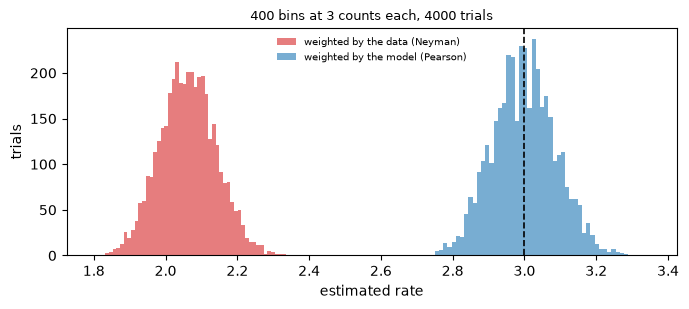

In [2]:
def fit_rate(y, weight):
    #: minimise sum w (y - a)^2 over a single amplitude a
    return float(np.sum(weight * y) / np.sum(weight))

lam = 3.0; n = 400
pearson, neyman = [], []
for _ in range(4000):
    y = rng.poisson(lam, n).astype(float)
    a = lam
    for _ in range(20):                       # Pearson: weight by the model, iterated
        a = fit_rate(y, np.full(n, 1.0 / max(a, 1e-9)))
    pearson.append(a)
    neyman.append(fit_rate(y, 1.0 / np.maximum(y, 1.0)))
pearson, neyman = np.array(pearson), np.array(neyman)
fig, ax = plt.subplots(figsize=(7.0, 3.2))
ax.hist(neyman, bins=60, alpha=0.6, color='C3', label='weighted by the data (Neyman)')
ax.hist(pearson, bins=60, alpha=0.6, color='C0', label='weighted by the model (Pearson)')
ax.axvline(lam, color='k', ls='--', lw=1.2)
ax.set_xlabel('estimated rate'); ax.set_ylabel('trials'); ax.legend(fontsize=7, frameon=False)
ax.set_title(f'{n} bins at {lam:g} counts each, 4000 trials', fontsize=9)
fig.tight_layout()
print(f'truth {lam:.4f}')
print(f'  weighted by the model: {pearson.mean():.4f}  (bias {100*(pearson.mean()-lam)/lam:+.2f} %)')
print(f'  weighted by the data:  {neyman.mean():.4f}  (bias {100*(neyman.mean()-lam)/lam:+.2f} %)')
print('\nthe biased estimator fits the data no worse. Nothing in a residual plot shows it.')

## 2. A truth that was not a decay (wrong answer, good fit)

The maps that turn a distance into basis amplitudes are precomputed. One of
them — the directly excited acceptor's anisotropy partner — carried a factor
of the acceptor's lifetime it should not have, because it was normalised by the
area of an already-normalised decay, which is one.

The consequence: for every simulated truth since the map was built, the
perpendicular channel of the directly excited acceptor had **negative expected
counts over its leading edge**. Negative expected counts are not a subtle
error. They were invisible because the positivity floor in the likelihood turns
them into approximately zero, and a fit to those data still converged and still
fitted.

Two things came out of it. The maps are versioned, so a corrected map cannot be
confused with the cache of an old one. And a truth is now checked before it is
ever used: **a truth must be a decay.** An intermediate iterate of a fit may go
negative — that is what the soft floor is for — but a simulated truth may not.

The cell fires that check on purpose.

In [3]:
S = bd.default_settings(); S['threads'] = 4
model = bd.build_model(S); L = model['L']
p_true = bd.gaussian_truth(model, [0.95], [1.0], 0.07)
lam_ok, vals, g0 = bd.expected_counts(model, S, p_true, 0.2, {'D0': 1e5, 'DA': 1e5, 'A0': 6e4})
print('a real truth passes the check:')
a2 = {k: L.instrument_amplitudes(vals, L.physics_amplitudes(model['Ep'], vals, model['Ep']['cD'],
                                                            L.tt(p_true), g0.keys)[k], k) for k in g0.keys}
g0.assert_physical(vals, a2, where='the truth of this notebook')
print('  passed.\n')
bad = dict(a2)
k_bad = [k for k in g0.keys if k[1].endswith('vh')][0]
v = a2[k_bad].clone(); v[3:9] = v[3:9] - 3.0 * v.abs().max()
bad[k_bad] = v
try:
    g0.assert_physical(vals, bad, where='a deliberately broken map')
    print('  the check did NOT fire, which would be the bug')
except ValueError as e:
    print('a broken map is caught:')
    print(' ', str(e)[:160])

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
a real truth passes the check:


  passed.

a broken map is caught:
  a deliberately broken map: negative expected counts in D0 gh_vh (min -8.22e+04 of peak 1.53e+03)


## 3. A gauge that depended on the machine (silent loss)

The softmax is shift invariant, so the spline coefficients carry one flat
direction that must be removed. Any orthonormal basis of the complement of the
constant vector does it, and **they all give the same distribution**.

They do not give the same *coordinates*. A posterior stored as numbers in one
basis is meaningless in another. The basis had been taken from the singular
vectors of a degenerate subspace — where the choice among equal singular values
is up to the linear-algebra library — so a posterior computed on one machine
restored wrongly on another. A thousand stored fits were affected, and the
symptom was not an error: it was distributions that had quietly rotated.

The cell shows both halves: the distribution is invariant, the coordinates are
not.

In [4]:
n_c = model['spl'].shape[1]
H = np.asarray(L.helmert_basis(n_c))
q, _ = np.linalg.qr(rng.normal(size=(n_c, n_c)))
alt = q[:, :n_c-1] - q[:, :n_c-1].mean(0)            # another basis of the same subspace
alt, _ = np.linalg.qr(alt)
c_tilde = rng.normal(size=n_c-1)
p_H = np.exp(np.asarray(model['spl']) @ (H @ c_tilde)); p_H /= p_H.sum()
same = H @ c_tilde
c_alt = alt.T @ same                                  # the SAME point, in the other basis
p_alt = np.exp(np.asarray(model['spl']) @ (alt @ c_alt)); p_alt /= p_alt.sum()
print(f'the same point in two bases gives the same distribution: '
      f'max |p_H - p_alt| = {np.abs(p_H - p_alt).max():.2e}')
print(f'but the coordinates differ by                             {np.abs(c_tilde - c_alt).max():.3f}')
p_wrong = np.exp(np.asarray(model['spl']) @ (alt @ c_tilde)); p_wrong /= p_wrong.sum()
print('reading one basis, numbers in the other gives a DIFFERENT distribution:')
print(f'  max |p - p_wrong| = {np.abs(p_H - p_wrong).max():.3f}, '
      f'mean R/R0 {float((p_H*model["rel"]).sum()):.3f} against {float((p_wrong*model["rel"]).sum()):.3f}')
print('\nno exception, no warning. Helmert contrasts are canonical, which is the fix.')

the same point in two bases gives the same distribution: max |p_H - p_alt| = 8.67e-18
but the coordinates differ by                             3.437
reading one basis, numbers in the other gives a DIFFERENT distribution:
  max |p - p_wrong| = 0.039, mean R/R0 1.015 against 1.093

no exception, no warning. Helmert contrasts are canonical, which is the fix.


## 4. A sliding window is not a burst (silent, and it changed a number)

`tttrlib`'s time-window search slides a window over the macro times and returns
every window that holds enough photons. Consecutive windows that pass belong to
**one molecule**, and taking them as separate bursts more than doubled the
burst count — 1729 "bursts" from 800 simulated molecules.

Nothing failed. The decays were still right, because they are built from the
photons and not from the burst list; but every per-burst quantity — the
classification of notebook 8, the burst-size distribution, the count itself —
was wrong.

molecules simulated            600
windows the search returned    1820
bursts after merging adjacent  542


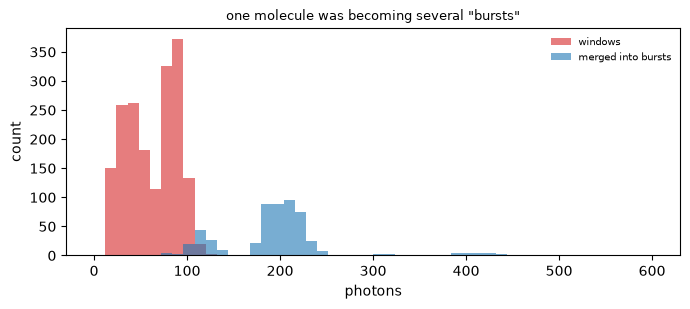

In [5]:
import pie_mfd as P
import tttrlib
S2 = dict(S); S2.update(n_bursts=600, n_bursts_donor=200, seed=5)
p2 = bd.truth_distribution(model, S2)
tab = bd.physics_tables(model, S2, p2, verbose=False)
stream = bd.simulate_stream(model, S2, p2, tab)
t = bd.to_tttr(model, stream['DA'])
mt = np.asarray(t.macro_times, dtype=np.uint64)
cal = model['period'] * 1e-9
raw = np.asarray(tttrlib.ranges_by_time_window(mt, S2['search_window_ms']*1e-3, -1.0,
                                               int(S2['search_min_photons']), -1, cal, False)).reshape(-1, 2)
sel, merged = bd.burst_search(model, t, S2)
print(f'molecules simulated            {len(stream["DA"]["bursts"])}')
print(f'windows the search returned    {len(raw)}')
print(f'bursts after merging adjacent  {len(merged)}')
sizes_raw = np.diff(raw, axis=1).ravel() + 1
sizes_m = np.array([b - a + 1 for a, b in merged])
fig, ax = plt.subplots(figsize=(7.0, 3.2))
ax.hist(sizes_raw, bins=50, range=(0, 600), alpha=0.6, color='C3', label='windows')
ax.hist(sizes_m, bins=50, range=(0, 600), alpha=0.6, color='C0', label='merged into bursts')
ax.set_xlabel('photons'); ax.set_ylabel('count'); ax.legend(fontsize=7, frameon=False)
ax.set_title('one molecule was becoming several "bursts"', fontsize=9)
fig.tight_layout()

## 5. Letting the root of the tree compete (a check that caught it)

The clustering of notebook 8 needs HDBSCAN's cluster-selection step, which the
library exposed everything else for but not itself. The excess-of-mass rule
walks the condensed tree keeping a node only when its own stability beats the
total stability of the selected clusters below it.

The first version walked **every** node, including the root. The root holds
every point from density zero, so its stability beats any set of descendants;
it was selected, everything below it was deselected, and the answer was one
cluster containing the sample.

On well-separated blobs this did not show, because the comparison against
`scikit-learn` agreed. It showed on **overlapping** blobs, which is why the
cross-check includes them — a check that cannot fail is not evidence.

In [6]:
from sklearn.cluster import HDBSCAN
from sklearn.metrics import adjusted_rand_score
import tttrlib

def select_with_root(parents, children, lam, size, n_points):
    #: the first version: the root is a candidate like any other node
    parents = np.asarray(parents, np.int64); children = np.asarray(children, np.int64)
    lam = np.asarray(lam, float); size = np.asarray(size, np.int64)
    nodes = np.unique(parents); root = int(nodes.min())
    birth = {int(c): float(l) for c, l in zip(children, lam) if c >= n_points}; birth[root] = 0.0
    stab = {int(c): 0.0 for c in nodes}
    for pa, l, sz in zip(parents, lam, size):
        stab[int(pa)] += float(sz) * (float(l) - birth[int(pa)])
    kids = {int(c): [] for c in nodes}
    for pa, ch in zip(parents, children):
        if ch >= n_points:
            kids[int(pa)].append(int(ch))
    sel = {int(c): True for c in nodes}
    for c in [int(x) for x in sorted(nodes, reverse=True)]:          # <-- the root included
        if not kids[c]:
            continue
        below, stack = 0.0, list(kids[c])
        while stack:
            k = stack.pop()
            if sel[k]:
                below += stab[k]
            else:
                stack.extend(kids[k])
        if stab[c] < below:
            sel[c] = False
        else:
            stack = list(kids[c])
            while stack:
                k = stack.pop(); sel[k] = False; stack.extend(kids[k])
    sel[root] = False
    out = np.zeros(int(max(int(nodes.max()), int(children.max()))) + 1, dtype=np.uint8)
    for c, v in sel.items():
        out[c] = 1 if v else 0
    return out

def labels_with(selector, X, mcs):
    mst = np.asarray(tttrlib.mutual_reachability_mst(np.ascontiguousarray(X), mcs, 1.0))
    mst = mst[np.argsort(mst[:, 2], kind='stable')]
    pa, ch, lm, sz = tttrlib.hdbscan_condensed_tree(np.ascontiguousarray(mst[:,0].astype(np.int64)),
                                                    np.ascontiguousarray(mst[:,1].astype(np.int64)),
                                                    np.ascontiguousarray(mst[:,2].astype(float)), mcs)
    isel = selector(pa, ch, lm, sz, len(X))
    lab = np.asarray(tttrlib.hdbscan_label_points(np.ascontiguousarray(np.asarray(pa, np.int64)),
                                                  np.ascontiguousarray(np.asarray(ch, np.int64)),
                                                  isel, len(X)))
    return lab

print(f"{'case':<28}{'with the bug':>16}{'fixed':>10}{'sklearn':>10}")
for name, sep, sd in (('well separated', 3.0, 0.25), ('overlapping', 1.2, 0.45)):
    r = np.random.default_rng(1)
    X = np.vstack([r.normal([0,0], sd, (200,2)), r.normal([sep,sep], sd, (200,2)),
                   r.normal([0,sep], sd, (150,2))])
    bug = labels_with(lambda *a: select_with_root(*a), X, 25)
    fix = bd.hdbscan_labels(X, 25, method='eom')
    ref = HDBSCAN(min_cluster_size=25, cluster_selection_method='eom', copy=True).fit_predict(X)
    print(f'{name:<28}{len(set(bug[bug>=0])):>16}{len(set(fix[fix>=0])):>10}{len(set(ref[ref>=0])):>10}'
          f'   clusters')
print('\non well-separated blobs the buggy version agrees with everything.')

case                            with the bug     fixed   sklearn
well separated                             3         3         3   clusters
overlapping                                1         3         2   clusters

on well-separated blobs the buggy version agrees with everything.


(The fixed version finds three clusters on the overlapping case where
scikit-learn finds two. That difference is the documented one: this library
assigns every point to a cluster while scikit-learn calls points outside the
selected clusters noise, so the points scikit-learn drops form a group here.
Notebook 8 measures the agreement over the points scikit-learn does cluster.)

## 6. Silent losses, which are the worst kind

Three of these produced no error, no warning, and no wrong number — they
produced **nothing**, and nothing looks like a clean run.

**The figures that were not drawn.** Importing part of the prototype calls
`matplotlib.use('Agg')`, because those modules were written for headless
scripts. After that, a notebook cell that draws a figure emits no output at
all. Three figures went missing from this series before it was noticed, in
notebooks whose text described them. `bd.keep_inline()` restores the backend
and blocks later switches; `bd.assert_inline()` is the check.

**The file that was destroyed by a string replace.** An edit computed a slice
between two markers, the second marker matched earlier in the file than the
first, the slice came out empty, and `str.replace('', new)` inserted the new
text between every character of the file — 1.1 million lines. Restored from the
last commit; every replacement since asserts that the pattern is present and
matches exactly once.

**The membership strengths that are not confidences.** A clustering reports a
strength per point that looks like a probability. It is a rank within its own
cluster — the denominator is that cluster's own death density — so a threshold
tuned on one clustering silently stops filtering on another. Caught before it
shipped, by someone who had measured it.

In [7]:
import matplotlib
print('the backend right now:', matplotlib.get_backend())
print('and the guard is in place:', bd.assert_inline())
for line in ['the failure looked like this: a cell containing plt.subplots(...) and a plot',
             'call finished in milliseconds, produced no output, and raised nothing. The',
             'notebook looked complete. Only counting the figures in the executed file',
             'found it.']:
    print(line)

the backend right now: inline
and the guard is in place: inline
the failure looked like this: a cell containing plt.subplots(...) and a plot
call finished in milliseconds, produced no output, and raised nothing. The
notebook looked complete. Only counting the figures in the executed file
found it.


## 7. Wrong answers that fit the data

These are the dangerous ones, because every diagnostic in this series passes on
them. Each is treated in the notebook that found it; they are listed together
here because the pattern is the point.

| what was done | what it produced | notebook |
|---|---|---|
| maximising over the roughness weight instead of integrating it | two populations flattened into one hump, at a deviance 2 % worse and inside the noise | 3 |
| a band drawn as a lognormal in $\log p$ | an upper edge nine times the posterior mean's peak, where the data say nothing | 4 |
| penalising $\sqrt p$ or $p$ instead of $\log p$ | structure preferentially in the tails, where the distribution is small | 3 |
| a third-difference penalty | narrower bands, the same bias — a worse interval, not a better one | 3, 5 |
| reading the design calculation from the conclusion | the claim that the red pulse buys the donor-only fraction; it buys the acceptor anisotropy | 6 |
| assuming a burst classification splits the sample | it peels off the populations' wings and leaves the overlap | 8 |

The last two are drafts of this series that its own cells contradicted. Both
are corrected in place, and both are worth naming because they were written by
someone who knew the answer before running the code.

## 8. A check that could not fail

The first cross-check of the clustering used three well-separated blobs.
Everything agrees on three well-separated blobs. The check was passed by an
implementation with a bug that turns the sample into one cluster, and it took
adding **overlapping** blobs — where the algorithm has a real choice to make —
before the check could fail, and then it did, immediately.

Two more of the same shape are recorded from earlier in the project: a
classification accuracy of 83 % that was measuring the majority class of a
collapsed model, and a network-against-ceiling comparison that reported 13.6 %
because two label sets were compared without matching their arbitrary indices.

The rule that came out of all three: **before running a check, ask what result
would make it fail.** If there isn't one, it is not a check.

## What comes next

Notebook 10 is the last: the model as a factor graph in bff, drawn and made
fast.